### USHER: Aligning Xenium Spatial Transcriptomics to scRNA-seq using scGPT Embeddings

This notebook demonstrates how to use **USHER** (Unified Strategy for Shifting Towards Established Representations) to align out-of-distribution spatial transcriptomics data (Xenium) to a reference scRNA-seq dataset using foundation model embeddings from scGPT.

#### Overview

The key challenge is that the scGPT foundation model embeddings for Xenium spatial transcriptomics and scRNA-seq data remain misaligned due to differences between the modalities. Here scRNA-seq is in-distribution with scGPT training data and Xenium is out-of-distribution, resulting in a distribution shift even in the embedding space causing disruption to downstream analysis.

**USHER learns a linear transformation** that shifts the Xenium embeddings toward the scRNA-seq embedding distribution, enabling better integration of spatial and single-cell data and pave way for downstream analysis using the aligned representations.

#### Workflow
1. Load pre-computed scGPT embeddings for both datasets
2. Visualize the initial embedding distributions (showing misalignment)
3. Run USHER alignment using Fused Gromov-Wasserstein optimal transport
4. Evaluate the aligned embeddings

## Setup and Imports

In [1]:
import os
# Ép Numba và OpenMP chỉ chạy 1 luồng để tránh sập Kernel trên Mac
os.environ["NUMBA_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

# Tắt luôn các cảnh báo rác của OpenMP
os.environ["KMP_WARNINGS"] = "0"

In [2]:
%load_ext autoreload
%autoreload 2


In [3]:
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import anndata as ad

print(f"scanpy: {sc.__version__}\n"
      f"pandas: {pd.__version__}\n"
      f"numpy: {np.__version__}\n"
      f"seaborn: {sns.__version__}\n"
      f"anndata: {ad.__version__}")

scanpy: 1.11.5
pandas: 2.3.3
numpy: 1.26.4
seaborn: 0.13.2
anndata: 0.11.4


/var/folders/y2/k7vr6kx52yz8600lm21_k0xc0000gn/T/ipykernel_49649/3606466239.py:8: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(f"scanpy: {sc.__version__}\n"


#### Data available from here:
https://drive.google.com/drive/folders/1U_VW--4BaTaxVQdYLuU1wOwg7aUQmkRU 
Download datasets from here and unpack into datasets/ directory. These files contain precomputed scGPT embeddings in 'adata.obsm['scGPT']'


#### Load Datasets

We load two AnnData objects containing pre-computed scGPT embeddings:
- **xenium_scGPT.h5ad**: Xenium spatial transcriptomics data (~38K cells, 342 genes)
- **scRNAseq_scGPT.h5ad**: Reference scRNA-seq data (~26K cells, 25K genes)

Both files contain scGPT embeddings stored in `adata.obsm['X_scGPT']`.

In [4]:
xenAD = sc.read_h5ad('../datasets/xenium_scGPT.h5ad')

scAD = sc.read_h5ad('../datasets/scRNAseq_scGPT.h5ad')


In [5]:
xenAD

AnnData object with n_obs × n_vars = 38280 × 342
    obs: 'sample', 'patient', 'cell_id', 'full_cell_id', 'sample_type', 'sample_affect', 'disease_status', 'percent_pathology', 'tma', 'run', 'final_CT', 'final_lineage', 'CNiche', 'TNiche', 'lumen_id', 'lumen_rank', 'x_centroid', 'y_centroid', 'adj_x_centroid', 'adj_y_centroid', 'super_adj_x_centroid', 'super_adj_y_centroid', 'nCount_RNA', 'nFeature_RNA', 'perc_negcontrolprobe', 'perc_negcontrolcodeword', 'perc_unassigned', 'perc_negcontrolorunassigned', 'nCount_niche', 'nFeature_niche', 'assay', 'sID', 'predicted_celltype'
    var: 'mean', 'std', 'gene_id', 'n_counts', 'index', 'id_in_vocab'
    uns: 'log1p'
    obsm: 'X_SP', 'X_celltype_probs', 'X_pca', 'X_scGPT', 'X_sp', 'X_umap', 'bin_edges'
    varm: 'PCs'
    layers: 'X_binned', 'X_log1p', 'X_normed'

In [6]:
scAD

AnnData object with n_obs × n_vars = 26323 × 25425
    obs: 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'Sample_Name', 'Diagnosis', 'Sample_Source', 'Sample_Type', 'Tobacco', 'Status', 'Flowcell_ID', 'Processing_site', 'Gender', 'Age', 'Ethnicity', 'S.Score', 'G2M.Score', 'Phase', 'nCount_SCT', 'nFeature_SCT', 'Short_Sample_Name', 'manual_annotation_1', 'annotation_level_1', 'annotation_level_2', 'lineage', 'assay', 'annotation_level_0', 'sID'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'gene_id', 'n_counts', 'index', 'id_in_vocab'
    uns: 'annotation_level_0_colors', 'log1p', 'neighbors', 'umap'
    obsm: 'X_celltype_probs', 'X_scGPT', 'X_umap', 'bin_edges'
    layers: 'X_binned', 'X_log1p', 'X_normed'
    obsp: 'connectivities', 'distances'

#### Data Exploration

Let's examine the key difference between the two modalities: **gene coverage**. Xenium captures only ~300 genes while scRNA-seq measures ~25,000 genes per cell. This fundamental difference in input data creates challenges for foundation model embeddings.

Text(0.5, 1.0, '\n Xenium')

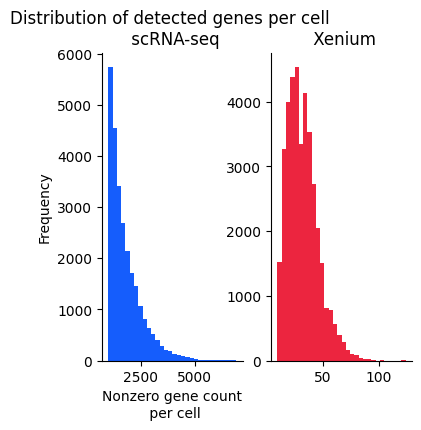

In [7]:

fig, ax = plt.subplots(1, 2, figsize=(4, 4))

counts, bins, _ = ax[1].hist((xenAD.X != 0).sum(axis=1), bins=30, color="#EC253F")

counts, bins, _ = ax[0].hist((scAD.X != 0).sum(axis=1), bins=30, color="#155DFC")
ax[0].set_xlabel("Nonzero gene count\n per cell")
ax[0].set_ylabel("Frequency")
ax[1].set_xlabel("")
ax[1].set_ylabel("")
ax[0].spines['right'].set_visible(False)
ax[0].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].spines['top'].set_visible(False)
ax[0].set_title("Distribution of detected genes per cell \n scRNA-seq")
ax[1].set_title("\n Xenium")



#### Prepare scGPT Embedding AnnData Objects

We create new AnnData objects where the main matrix `X` contains the scGPT embeddings (512 dimensions). This allows us to use standard scanpy/rapids-singlecell functions for downstream analysis.

In [8]:
xenAD_scGPT = ad.AnnData(X= xenAD.obsm['X_scGPT'], obs= xenAD.obs, obsm=xenAD.obsm)
xenAD_scGPT.obs['assay'] = 'Xenium'
xenAD_scGPT.obs['cell_type'] = xenAD.obs['predicted_celltype']
scAD_scGPT = ad.AnnData(X= scAD.obsm['X_scGPT'], obs= scAD.obs, obsm=scAD.obsm)
scAD_scGPT.obs['assay'] = 'scRNA-seq'
scAD_scGPT.obs['cell_type'] = scAD.obs['annotation_level_0']

combinedAD = ad.concat([xenAD_scGPT, scAD_scGPT], axis=0, label='batch')

#### Compute UMAP Embeddings

We compute neighbor graphs and UMAP embeddings using cosine distance to visualize the embedding spaces.

In [9]:
# Chạy từng cái một để tránh quá tải
sc.pp.neighbors(xenAD_scGPT, use_rep='X', metric='cosine')
sc.tl.umap(xenAD_scGPT)
print("Xong xenAD!")

sc.pp.neighbors(scAD_scGPT, use_rep='X', metric='cosine')
sc.tl.umap(scAD_scGPT)
print("Xong scAD!")

sc.pp.neighbors(combinedAD, use_rep='X', metric='cosine')
sc.tl.umap(combinedAD)
print("Xong combinedAD!")

/usr/local/Caskroom/miniforge/base/envs/fds_arm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Xong xenAD!
Xong scAD!
Xong combinedAD!


In [10]:
ctype_palette = sc.pl.palettes.default_20
ctype_colors = {ct: c for ct, c in zip(sorted(combinedAD.obs['cell_type'].unique()), ctype_palette)}
assay_colors = {'Xenium': '#EC253F', 'scRNA-seq':'#155DFC'}

In [11]:
ctype_palette = sc.pl.palettes.default_20
ctype_colors = {ct: c for ct, c in zip(sorted(combinedAD.obs['cell_type'].unique()), ctype_palette)}
assay_colors = {'Xenium': '#EC253F', 'scRNA-seq':'#155DFC'}

Text(0.5, 1.0, 'Cell type')

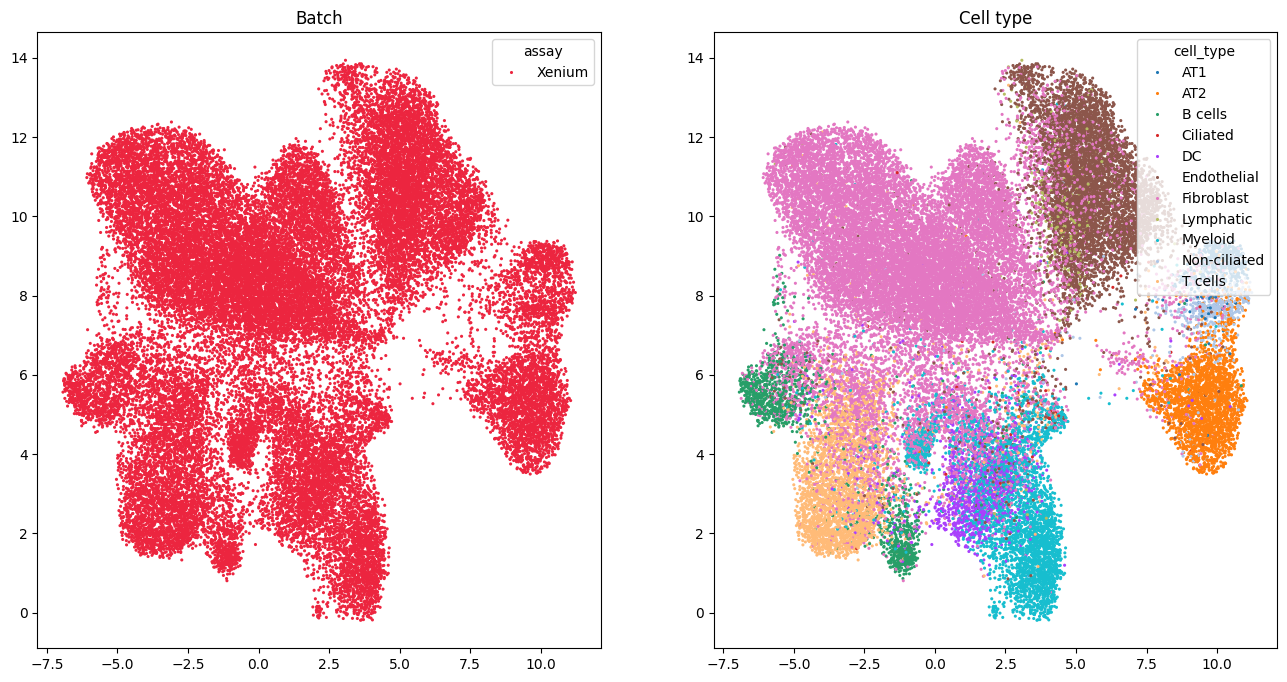

In [12]:


fig, ax = plt.subplots(1, 2, figsize=(16, 8))

sns.scatterplot(x=xenAD_scGPT.obsm['X_umap'][:, 0], y=xenAD_scGPT.obsm['X_umap'][:, 1], hue=xenAD_scGPT.obs['assay'], palette=assay_colors, s=5, linewidth=0, ax=ax[0])
sns.scatterplot(x=xenAD_scGPT.obsm['X_umap'][:, 0], y=xenAD_scGPT.obsm['X_umap'][:, 1], hue=xenAD_scGPT.obs['cell_type'], palette=ctype_colors, s=5, linewidth=0, ax=ax[1])

ax[0].set_title('Batch')
ax[1].set_title('Cell type')





Text(0.5, 1.0, 'Cell type')

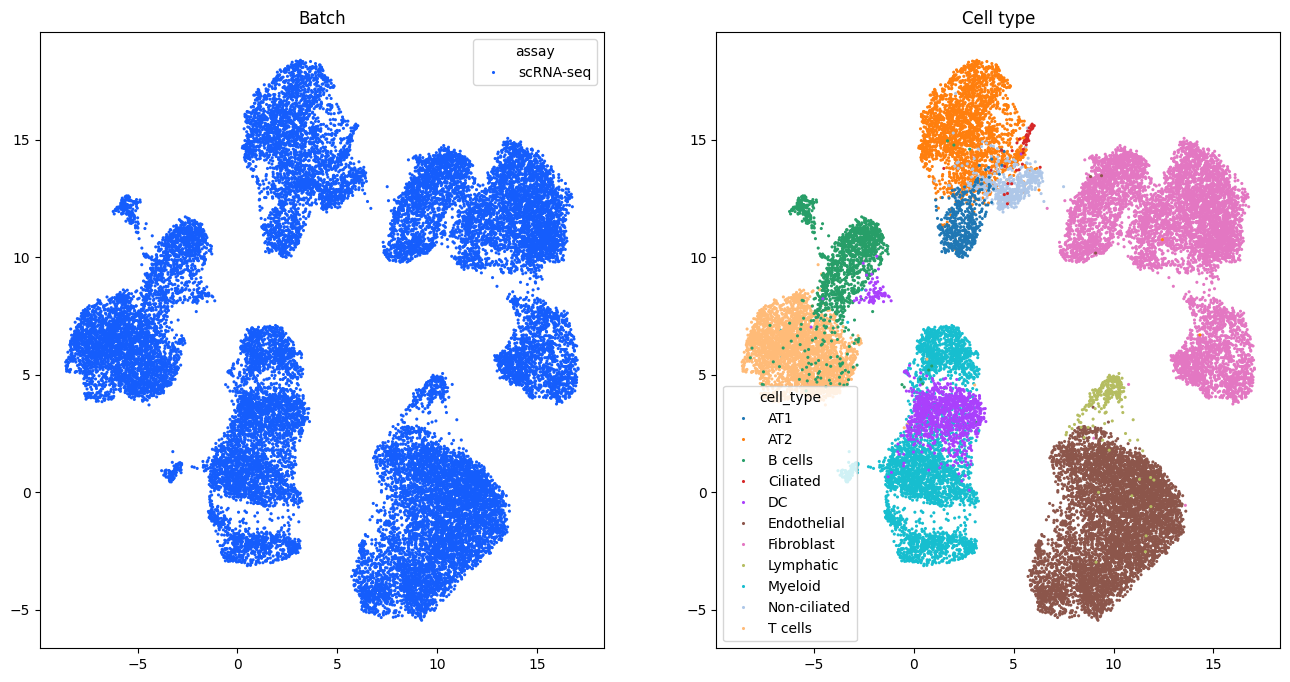

In [13]:


fig, ax = plt.subplots(1, 2, figsize=(16, 8))

sns.scatterplot(x=scAD_scGPT.obsm['X_umap'][:, 0], y=scAD_scGPT.obsm['X_umap'][:, 1], hue=scAD_scGPT.obs['assay'], palette=assay_colors, s=5, linewidth=0, ax=ax[0])
sns.scatterplot(x=scAD_scGPT.obsm['X_umap'][:, 0], y=scAD_scGPT.obsm['X_umap'][:, 1], hue=scAD_scGPT.obs['cell_type'], palette=ctype_colors, s=5, linewidth=0, ax=ax[1])

ax[0].set_title('Batch')
ax[1].set_title('Cell type')



Text(0.5, 1.0, 'Cell type')

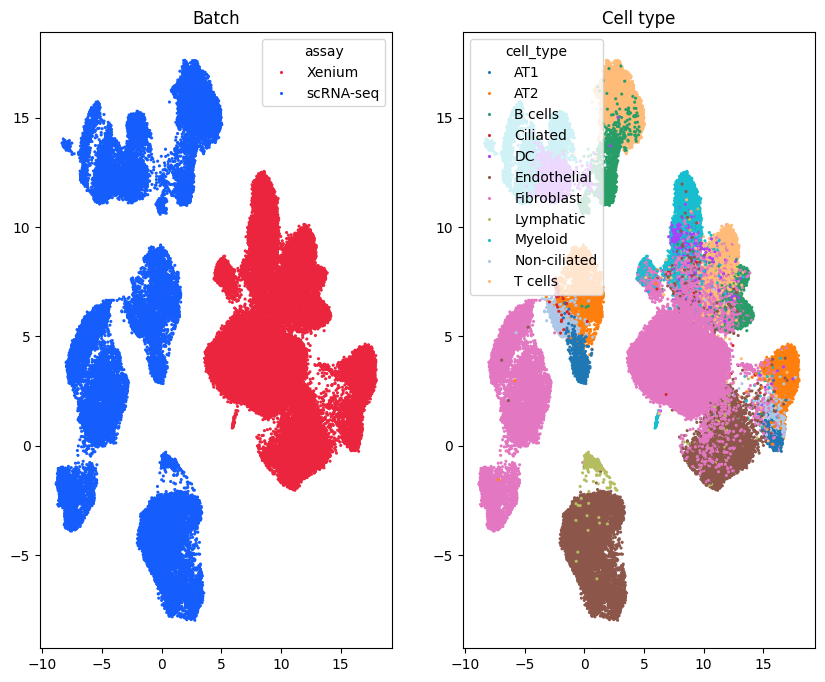

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(10, 8))

sns.scatterplot(x=combinedAD.obsm['X_umap'][:, 0], y=combinedAD.obsm['X_umap'][:, 1], hue=combinedAD.obs['assay'], palette=assay_colors, s=5, linewidth=0, ax=ax[0])
sns.scatterplot(x=combinedAD.obsm['X_umap'][:, 0], y=combinedAD.obsm['X_umap'][:, 1], hue=combinedAD.obs['cell_type'], palette=ctype_colors, s=5, linewidth=0, ax=ax[1])

ax[0].set_title('Batch')
ax[1].set_title('Cell type')


In [ ]:
import sys
sys.path.append('../src/')


In [ ]:

import cProfile
import pstats
import io
from run_usher import align_features_fgw

profiler = cProfile.Profile()
profiler.enable()

model, mapping_final, concat_adata, T_full, scaler_mean, scaler_std = align_features_fgw(
    xenAD_scGPT.copy(),
    scAD_scGPT.copy(),
    e_step_method="fgw",
    alpha=0.3, 
    lambda_cross=0.9,
    lambda_var=0.1,
    cell_type_col="cell_type",
    celltype_probs_layer="X_celltype_probs",
    sketch_size=4300,
    use_stratified_pairing=True,
    knn_k=30,
    metric="cosine",
    m_step_metric="euclidean",
    gamma=0.,
    epsilon=0.05,
    use_linear_assignment=True,
    sinkhorn_iters=1000,
    n_iters=10,
    steps_per_iter=100,
    lr=1e-3,
    hidden_dim=512,
    debug_plots_path=None,)

profiler.disable()


s = io.StringIO()
ps = pstats.Stats(profiler, stream=s).sort_stats('cumulative')
ps.print_stats(25)  
print(s.getvalue())

profiler.dump_stats("usher_profile.prof")



Exception ignored When destroying _lsprof profiler:
Traceback (most recent call last):
  File "/var/folders/y2/k7vr6kx52yz8600lm21_k0xc0000gn/T/ipykernel_49649/2149484849.py", line 7, in <module>
RuntimeError: Cannot install a profile function while another profile function is being installed
2026-09-03 16:37:04,109 - INFO - Using device: mps
2026-09-03 16:37:07,089 - INFO - Source (A): 38280 spots, 512 features. Target (B): 26323 spots, 512 features.
2026-09-03 16:37:07,090 - INFO - E-step method: fgw
2026-09-03 16:37:07,090 - INFO - M-step method: global
2026-09-03 16:37:07,090 - INFO - M-step method: global (lr=0.001, steps_per_iter=100)
2026-09-03 16:37:07,091 - INFO - Distance metric (kNN/UMAP/M-step loss): cosine
2026-09-03 16:37:07,091 - INFO - kNN graph: enabled (k=30)
2026-09-03 16:37:07,091 - INFO - Gamma (feature weight in M): 0.0 (iter 0 uses gamma=0)
2026-09-03 16:37:07,091 - INFO - === Using CELLTYPE sampling strategy ===
2026-09-03 16:37:07,092 - INFO - Chạy chế độ FULL 

                             nCount_RNA  nFeature_RNA   assay  \
VUILD49LA_bepaenan-1_source        47.0          29.0  Xenium   
VUILD49LA_bfdmbnaf-1_source        42.0          32.0  Xenium   
VUILD49LA_bffagdhb-1_source       226.0          76.0  Xenium   
VUILD49LA_bgnbogll-1_source        59.0          44.0  Xenium   
VUILD49LA_fonokhha-1_source        33.0          28.0  Xenium   

                                              sID     cell_type  \
VUILD49LA_bepaenan-1_source  VUILD49LA_bepaenan-1  Non-ciliated   
VUILD49LA_bfdmbnaf-1_source  VUILD49LA_bfdmbnaf-1  Non-ciliated   
VUILD49LA_bffagdhb-1_source  VUILD49LA_bffagdhb-1  Non-ciliated   
VUILD49LA_bgnbogll-1_source  VUILD49LA_bgnbogll-1  Non-ciliated   
VUILD49LA_fonokhha-1_source  VUILD49LA_fonokhha-1  Non-ciliated   

                                           type   batch  
VUILD49LA_bepaenan-1_source  source_transformed  source  
VUILD49LA_bfdmbnaf-1_source  source_transformed  source  
VUILD49LA_bffagdhb-1_source  sou

2026-09-03 16:46:27,261 - INFO - Final UMAP computation successful
2026-09-03 16:46:27,262 - INFO - Alignment completed. Final mapping: 38280/38280 source cells mapped
2026-09-03 16:46:27,262 - INFO - Reconstructing full transport matrix for output...
2026-09-03 16:46:27,489 - INFO -   [Output Bypass] T_full taken directly from single batch (0 Bytes extra RAM used).
2026-09-03 16:46:27,520 - INFO - Model saved to ../datasets/scGPT_example/alignment_model.pt (with feature scaler)
2026-09-03 16:46:27,521 - INFO - Model saved to ../datasets/scGPT_example/alignment_model.pt


         4073339 function calls (3896011 primitive calls) in 564.247 seconds

   Ordered by: cumulative time
   List reduced from 4687 to 25 due to restriction <25>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        2    0.000    0.000  564.248  282.124 /usr/local/Caskroom/miniforge/base/envs/fds_arm/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3543(run_code)
      8/2    0.001    0.000  564.248  282.124 {built-in method builtins.exec}
        1    0.023    0.023  564.248  564.248 /var/folders/y2/k7vr6kx52yz8600lm21_k0xc0000gn/T/ipykernel_49649/2149484849.py:1(<module>)
        1    0.086    0.086  563.418  563.418 /Users/HIEU/Workspaces/Projects/FDS/example_notebooks/../src_new/run_usher.py:60(align_features_fgw)
       10    0.004    0.000  394.266   39.427 /Users/HIEU/Workspaces/Projects/FDS/example_notebooks/../src_new/run_usher.py:530(process_cluster)
       10    0.382    0.038  394.235   39.423 /Users/HIEU/Workspaces/Projects/FDS/ex

### Load a Saved USHER Model
You can reload a previously trained alignment model for downstream analysis or application to new data. Note that this model can now be used to align any new Xenium data with similar gene panel (not just the one used for training).

Here, we load a saved USHER model from the `datasets/scGPT_example/` directory.
 Make sure the path matches the location where the model was saved after training.


In [25]:
#load learned transformation
from model_utils import *
model, scaler_mean,scaler_std, gene_names = load_alignment_model('../datasets/scGPT_example/alignment_model.pt', hidden_dim=512)

2026-09-03 16:46:44,995 - INFO - Model loaded from ../datasets/scGPT_example/alignment_model.pt to mps (with feature scaler)


In [ ]:
import torch
import anndata as ad
import sys
sys.path.append('../src/') # Đảm bảo đường dẫn này trỏ đúng vào thư mục source code

from model_utils import load_alignment_model, _to_dense_float32
from m_step_utils import standardize_features, unstandardize_features

print("1. Đang tải mô hình USHER đã huấn luyện...")
# ⚠️ THAY ĐỔI ĐƯỜNG DẪN NÀY ĐÚNG VỚI NƠI LƯU MODEL CỦA BẠN
model_path = '../datasets/scGPT_example/alignment_model.pt' 
model, scaler_mean, scaler_std, gene_names = load_alignment_model(model_path, hidden_dim=512)

print("2. Đang chuẩn bị dữ liệu Xenium...")
xenAD_scGPT_aligned = xenAD_scGPT.copy()
X_new = _to_dense_float32(xenAD_scGPT_aligned.X)

# Nhận diện thiết bị (Mac MPS, Nvidia CUDA, hoặc CPU)
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
X_new = torch.from_numpy(X_new).to(device)

print(f"3. Đang áp dụng phép biến đổi USHER (Inference) trên {device.upper()}...")
# Chuẩn hóa dữ liệu đầu vào bằng scaler của mô hình đã lưu
X_new_std = standardize_features(X_new, scaler_mean, scaler_std)
features_new = X_new_std.to(device)

# Chạy mô hình để tạo feature mới (không tính toán gradient)
with torch.no_grad():
    features_transformed = model(features_new)

# Đảo chuẩn hóa để đưa về không gian gốc
features_transformed = unstandardize_features(features_transformed, scaler_mean, scaler_std)

# Tạo AnnData mới chứa embedding đã được align
xenAD_scGPT_aligned = ad.AnnData(
    X=features_transformed.detach().cpu().numpy(), 
    obs=xenAD_scGPT_aligned.obs,
    obsm=xenAD_scGPT_aligned.obsm
)

print("4. Tạo 'concat_adata' cho hệ thống Benchmark...")
# Gộp dữ liệu Xenium (đã align) và scRNA-seq (Target)
# Lưu ý: Cố ý đặt tên biến là 'concat_adata' để khớp với cell chạy scib-metrics
concat_adata = ad.concat([xenAD_scGPT_aligned, scAD_scGPT], axis=0, label='batch')

print("✅ Đã hoàn tất! Biến 'concat_adata' đã sẵn sàng. Bạn có thể chạy cell Benchmark ngay bây giờ.")

#### Apply USHER Transformation to New Data

Now that we've loaded the trained USHER model, we can apply the learned linear transformation to align our Xenium embeddings to the scRNA-seq embedding space.

The transformation pipeline involves:
1. **Standardize features** - Apply the same feature scaling used during training (since the W model was trained on standardized scRNA-seq embeddings for stability)
2. **Transform embeddings** - Pass through the learned alignment model
3. **Unstandardize** - Convert back to the original scale

This process shifts the Xenium embeddings toward the scRNA-seq distribution without modifying the reference data.

In [26]:
xenAD_scGPT_aligned = xenAD_scGPT.copy()

In [27]:
import torch
# Load and convert data
from model_utils import _to_dense_float32
X_new = _to_dense_float32(xenAD_scGPT_aligned.X)
device = 'cuda' if torch.cuda.is_available() else 'mps'
X_new = torch.from_numpy(X_new).to(device)
from m_step_utils import standardize_features, unstandardize_features
X_new_std = standardize_features(X_new, scaler_mean, scaler_std)

features_new = X_new_std.to(device)
with torch.no_grad():
    features_transformed = model(features_new)
features_transformed = unstandardize_features(features_transformed, scaler_mean, scaler_std)
xenAD_scGPT_aligned = ad.AnnData(X=features_transformed.detach().cpu().numpy(), obs=xenAD_scGPT_aligned.obs,obsm=xenAD_scGPT_aligned.obsm)

#### Create Combined Dataset

With the Xenium embeddings now aligned to the scRNA-seq space, we concatenate both datasets into a single AnnData object. This combined dataset enables joint analysis and visualization of both modalities in a shared embedding space.

In [28]:
combinedAD_aligned = ad.concat([xenAD_scGPT_aligned, scAD_scGPT], axis=0, label='batch')

In [29]:
sc.pp.neighbors(combinedAD_aligned, use_rep='X', metric='cosine')
sc.tl.umap(combinedAD_aligned)


Text(0.5, 1.0, 'Cell type')

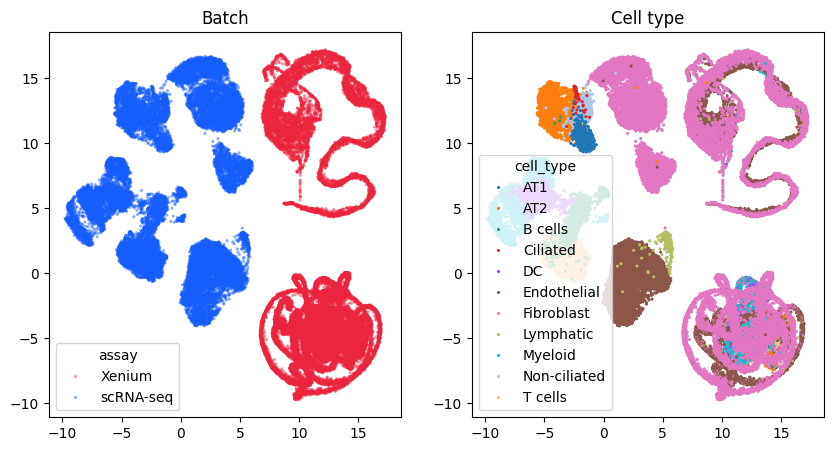

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

sns.scatterplot(x=combinedAD_aligned.obsm['X_umap'][:, 0], y=combinedAD_aligned.obsm['X_umap'][:, 1], hue=combinedAD_aligned.obs['assay'], palette=assay_colors, s=5, linewidth=0, ax=ax[0], alpha=0.5)
sns.scatterplot(x=combinedAD_aligned.obsm['X_umap'][:, 0], y=combinedAD_aligned.obsm['X_umap'][:, 1], hue=combinedAD_aligned.obs['cell_type'], palette=ctype_colors, s=5, linewidth=0, ax=ax[1])

ax[0].set_title('Batch')
ax[1].set_title('Cell type')


In [31]:
import scib_metrics.utils._silhouette as sil_utils
import scib_metrics.metrics._silhouette as metrics_sil_utils
import scib_metrics.metrics._nmi_ari as nmi_ari_mod
from sklearn.metrics import silhouette_samples as sk_silhouette_samples
from sklearn.cluster import KMeans as SklearnKMeans
import numpy as np
import pandas as pd
import scanpy as sc
from scib_metrics.benchmark import Benchmarker
import jax

# 1. Cấu hình an toàn cho JAX
jax.config.update("jax_enable_x64", False)

# 2. Vá hàm silhouette_samples
def patched_silhouette_samples(X, labels, chunk_size=None, metric="euclidean", between_cluster_distances=None):
    if hasattr(X, "detach"):
        X_np = X.detach().cpu().numpy()
    elif hasattr(X, "toarray"):
        X_np = X.toarray()
    else:
        X_np = np.asarray(X)
        
    if isinstance(labels, pd.Categorical):
        labels_codes = labels.codes
    else:
        labels_arr = np.array(labels)
        if not np.issubdtype(labels_arr.dtype, np.integer):
            labels_codes = pd.Categorical(labels_arr).codes
        else:
            labels_codes = labels_arr
            
    return sk_silhouette_samples(X_np, labels_codes, metric=metric)

sil_utils.silhouette_samples = patched_silhouette_samples
metrics_sil_utils.silhouette_samples = patched_silhouette_samples

# 3. Vá K-Means
def patched_compute_clustering_kmeans(X, n_clusters):
    if hasattr(X, "detach"):
        X_np = X.detach().cpu().numpy()
    elif hasattr(X, "toarray"):
        X_np = X.toarray()
    else:
        X_np = np.asarray(X)
        
    kmeans = SklearnKMeans(n_clusters=n_clusters, n_init=10, random_state=42)
    kmeans.fit(X_np)
    return kmeans.labels_

nmi_ari_mod._compute_clustering_kmeans = patched_compute_clustering_kmeans

print("=== ĐÁNH GIÁ CHẤT LƯỢNG TÍCH HỢP (SCIB-METRICS CHUẨN USHER) ===")

# 4. Đảm bảo dữ liệu đầu vào đã có PCA
if 'X_pca' not in concat_adata.obsm:
    sc.tl.pca(concat_adata)

sc.pp.neighbors(concat_adata, use_rep='X_pca', n_neighbors=50)

# 5. Khởi tạo Benchmarker
bm = Benchmarker(
    concat_adata,
    batch_key="batch",          
    label_key="cell_type",      
    embedding_obsm_keys=["X_pca"], 
    n_jobs=-1                   
)

print("Đang chạy toàn bộ hệ thống đánh giá (Vui lòng đợi trong giây lát)...")
bm.benchmark()

# Lấy kết quả dưới dạng Pandas DataFrame
results_df = bm.get_results(min_max_scale=False)
print("\n📋 Các cột có sẵn trong kết quả:", results_df.columns.tolist())

# 6. Hàm trích xuất cột an toàn (chống KeyError)
def get_safe_metric(df, keys):
    for k in keys:
        if k in df.columns:
            return df.loc['X_pca', k]
    for col in df.columns:
        if any(k.lower() in col.lower() for k in keys):
            return df.loc['X_pca', col]
    return 0.0

metric_asw = get_safe_metric(results_df, ['Silhouette label', 'silhouette_label', 'Silhouette'])
metric_ilisi = get_safe_metric(results_df, ['iLISI', 'ilisi'])
metric_kbet = get_safe_metric(results_df, ['KBET', 'kbet'])
metric_bras = get_safe_metric(results_df, ['Silhouette batch', 'silhouette_batch', 'bras', 'BRAS'])

print("\n" + "="*50)
print(f"🌟 BẢNG BENCHMARK (USHER - THEO CHUẨN SCIB-METRICS) 🌟")
print("="*50)
print(f"▶ Cell-Type ASW (Bio Conservation) : {metric_asw:.4f}  (Lý tưởng: 1.0)")
print(f"▶ BRAS Score (Batch + Bio balance) : {metric_bras:.4f}  (Lý tưởng: 1.0)")
print(f"▶ iLISI Score (Batch Mixing)       : {metric_ilisi:.4f}  (Lý tưởng: 1.0)")
print(f"▶ KBET Score  (Batch Acceptance)   : {metric_kbet:.4f}  (Lý tưởng: 1.0)")
print("="*50)

=== ĐÁNH GIÁ CHẤT LƯỢNG TÍCH HỢP (SCIB-METRICS CHUẨN USHER) ===
Đang chạy toàn bộ hệ thống đánh giá (Vui lòng đợi trong giây lát)...


/usr/local/Caskroom/miniforge/base/envs/fds_arm/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(
Embeddings:   0%|          | 0/1 [00:00<?, ?it/s]2026-09-03 16:48:44,028 - INFO - isolated labels: no more than 2 batches per label
INFO:2026-09-03 16:48:44,065:jax._src.xla_bridge:752: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/usr/local/Caskroom/miniforge/base/envs/fds_arm/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
2026-09-03 16:48:44,065 - INFO - Unable to init


📋 Các cột có sẵn trong kết quả: ['Isolated labels', 'KMeans NMI', 'KMeans ARI', 'Silhouette label', 'cLISI', 'BRAS', 'iLISI', 'KBET', 'Graph connectivity', 'PCR comparison', 'Batch correction', 'Bio conservation', 'Total']

🌟 BẢNG BENCHMARK (USHER - THEO CHUẨN SCIB-METRICS) 🌟
▶ Cell-Type ASW (Bio Conservation) : 0.3755  (Lý tưởng: 1.0)
▶ BRAS Score (Batch + Bio balance) : 0.3424  (Lý tưởng: 1.0)
▶ iLISI Score (Batch Mixing)       : -0.0000  (Lý tưởng: 1.0)
▶ KBET Score  (Batch Acceptance)   : 0.0000  (Lý tưởng: 1.0)
